# **Laboratorio 9: Airflow 🛫**

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Hayter Cortés Muñoz
- Nombre de alumno 2: Robert Collins Dätwyler.

### **Link de repositorio de GitHub:** [Repositorio del grupo](https://github.com/HayterCortes/lab-programacion-cientifica-para-ciencia-de-datos)

## Temas a tratar

- Construcción de pipelines productivos usando `Airflow`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Reconocer los componentes pricipales de `Airflow` y su funcionamiento.
- Poner en práctica la construcción de pipelines de `Airflow`.
- Automatizar procesos típicos de un proyecto de ciencia de datos mediante `Airflow` y `Docker`.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# **Introducción**

<p align="center">
  <img src="https://media.tenor.com/OBQ6niqbxswAAAAM/legallyblonde.gif" width="300">
</p>

Vale, una estudiante del Magíster en Ciencia de Datos, se encuentra en la etapa final de sus estudios. Por un lado, está muy contenta por haber llegado tan lejos, pero por otro, no puede evitar sentirse inquieta. Desde que ingresó a la universidad, una pregunta la ha perseguido: ¿qué tan probable es que pueda ser seleccionada en los lugares donde envíe postulaciones para puestos de trabajo?

Esta duda la mantiene en constante reflexión, especialmente porque sabe que el mercado laboral en Ciencia de Datos es competitivo y exige habilidades no solo técnicas, sino también estratégicas para destacar. Sin embargo, Vale actualmente está completamente enfocada en terminar su tesis de magíster y ha tenido que postergar cualquier preparación específica para enfrentar el desafío de las postulaciones laborales.

Al ver el avance y las habilidades que usted ha demostrado en el curso, Vale decidió proponerle un desafío que le permitirá disminuir la incertidumbre sobre su futuro laboral. Inspirado en sus conocimientos, recolectó un conjunto de datos que contiene información sobre diversos factores que influyen en las decisiones de contratación de empresas al seleccionar entre sus postulantes. Este set de datos incluye los siguientes atributos:

- Age: Edad del candidato
- Gender: Genero del candidato. Male (0), Female (1).
- EducationLevel: Mayor nivel educacional alcanzado por el candidato. Licenciatura Tipo 1 (1), Licenciatura Tipo 2 (2), Maestría (3), PhD. (4).
- ExperienceYears: Años de experiencia profesional.
- PreviousCompanies: Numero de compañías donde el candidato ha trabajado anteriormente.
- DistanceFromCompany: Distancia en kilometros entre la residencia del candidato y la compañía donde postula.
- InterviewScore: Puntaje obtenido en la entrevista por el candidato entre 0 a 100.
- SkillScore: Puntaje obtenido en evaluación de habilidades técnicas por el candidato, entre 0 a 100.
- PersonalityScore: Puntaje obtenido en pruebas de personalidad del candidato, entre 0 a 100.
- RecruitmentStrategy: Estrategia del equipo de reclutamiento. Agresiva (1), Moderada (2), Conservadora (3).

Variable a predecir:
- HiringDecision: Resultado de la postulación. No contratado (0), Contratado (1).

Su objetivo será ayudar a Vale a desarrollar un modelo que le permita predecir, basado en estos factores, si un postulante será contratado o no. Esta herramienta no solo le dará a Vale mayor claridad sobre el impacto de ciertos atributos en la decisión final de contratación, sino que también le permitirá aplicar sus conocimientos de Ciencia de Datos para resolver una pregunta que a muchos estudiantes como a ella les inquieta.

Como estudiante del curso Laboratorio de Programación Científica para Ciencia de Datos, deberá demostrar sus capacidades para preprocesar, analizar y modelar datos, brindándole a Vale una solución robusta y bien fundamentada para su problemática.

`Nota:` El siguiente [enlace](https://www.kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data/data) contiene el set de datos original.

# **1. Pipeline de Predicción Lineal** (30 Puntos)

<p align="center">
  <img src="https://media.licdn.com/dms/image/v2/D4E22AQHZplrdPyKnvA/feedshare-shrink_2048_1536/feedshare-shrink_2048_1536/0/1713736729086?e=2147483647&v=beta&t=Tad2ulaWkhhDrPRN0PCdXrfuza60PjoJqgLborDyLao" width="500">
</p>

En esta sección buscaremos desplegar un producto utilizando un modelo de clasificación `Random Forest` para determinar **si una persona será contratada o no en un proceso de selección**. Para ello, comenzaremos preparando un pipeline lineal mediante `Airflow`.

## **1.1 Preparando el Pipeline** (15 puntos)

**Primero, asegúrese de tener creada las carpetas `dags`, `plugins` y `logs`**.

Comenzamos preparando un archivo llamado `hiring_functions.py`, el cual guardará en la carpeta `dags` y debe contener lo siguiente:

1. (3 puntos) Una función llamada `create_folders()` que cree una carpeta, la cual utilice la fecha de ejecución como nombre. Adicionalmente, dentro de esta carpeta debe crear las siguientes subcarpetas:
  - raw
  - splits
  - models

  `Hint`: Puede hacer uso de kwargs para obtener la fecha de ejecución mediante el DAG. El siguiente [Enlace](https://airflow.apache.org/docs/apache-airflow/stable/templates-ref.html) le puede ser útil.

2. (3 puntos) Una función llamada `split_data()` que lea el archivo `data_1.csv` de la carepta `raw` y a partir de este, aplique un *hold out*, generando un dataset de entrenamiento y uno de prueba. Luego debe guardar estos nuevos conjuntos de datos en la carpeta `splits`. `Nota:` Utilice un 20% para el conjunto de prueba, mantenga la proporción original en la variable objetivo y fije una semilla.

3. (8 puntos) Cree una función llamada `preprocess_and_train()` que:
  - Lea los set de entrenamiento y prueba de la carpeta `splits`.
  - Cree y aplique un `Pipeline` con una etapa de preprocesamiento. Utilice `ColumnTransformers` para aplicar las transformaciones que estime convenientes. Puede apoyarse del archivo `data_1_report.html` para justificar cualquier paso del preprocesamiento.
  
  - Añada una etapa de entrenamiento utilizando el modelo `RandomForest`.
  
  Esta función **debe crear un archivo `joblib` (análogo a `pickle`) con el pipeline entrenado** en la carepta `models`, además debe **imprimir** el accuracy en el conjunto de prueba y el f1-score de la clase positiva (contratado).
3. (1 punto) Incorpore la función `gradio_interface` en su script, modificando la ruta de acceso a su modelo, de forma que pueda leerlo desde la carepta `models`. Puede realizar las modificaciones que estime necesarias.

`NOTA:` Se permite la creación de funciones auxiliares si lo estiman conveniente.

In [ ]:
import pandas as pd
import joblib
import gradio as gr
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Creación de Carpetas 

def create_folders(**kwargs):
    """
    Crea una estructura de carpetas basada en la fecha de ejecución (ds).
    Pasa las rutas de las carpetas creadas vía XCom.
    """
    # fecha de ejecución del contexto de Airflow
    execution_date = kwargs['ds']

    # ruta base en el directorio de trabajo actual
    base_path = Path.cwd() / execution_date

    # subcarpetas
    raw_path = base_path / 'raw'
    splits_path = base_path / 'splits'
    models_path = base_path / 'models'

    # todas las carpetas
    for path in [base_path, raw_path, splits_path, models_path]:
        path.mkdir(parents=True, exist_ok=True)

    print(f"Carpetas creadas en: {base_path}")

    # diccionario con las rutas para que Airflow las pase por XCom
    return {
        'base_path': str(base_path),
        'raw_path': str(raw_path),
        'splits_path': str(splits_path),
        'models_path': str(models_path)
    }

# 2. División de Datos 

def split_data(**kwargs):
    """
    Lee los datos de 'raw', aplica hold-out (80/20) estratificado
    y guarda los sets de train/test en 'splits'.

    Depende de:
    - XCom de la tarea 'create_folders'.
    - El archivo 'data_1.csv' debe estar presente en la carpeta 'raw'
      correspondiente a la fecha de ejecución.
    """
    # rutas desde la tarea anterior vía XCom
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders') 

    raw_path = Path(paths['raw_path'])
    splits_path = Path(paths['splits_path'])

    input_file = raw_path / 'data_1.csv'

    # Verificación de que el archivo existe
    if not input_file.exists():
        error_msg = (
            f"ERROR: El archivo '{input_file}' no se encuentra. "
            "Por favor, asegúrese de que 'data_1.csv' esté en la carpeta 'raw' "
            "antes de ejecutar esta tarea."
        )
        print(error_msg)
        raise FileNotFoundError(error_msg)

    print(f"Leyendo datos de: {input_file}")
    df = pd.read_csv(input_file)

    # features (X) y target (y)
    TARGET = 'HiringDecision'
    X = df.drop(TARGET, axis=1)
    y = df[TARGET]

    # Split 80/20 estratificado con semilla
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.20, 
        random_state=42,  # Semilla fija
        stratify=y         # Mantener proporción de la variable objetivo
    )

    # X e y para guardar los archivos CSV completos
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    # rutas de salida
    train_output = splits_path / 'train.csv'
    test_output = splits_path / 'test.csv'

    train_df.to_csv(train_output, index=False)
    test_df.to_csv(test_output, index=False)

    print(f"Datos de entrenamiento guardados en: {train_output}")
    print(f"Datos de prueba guardados en: {test_output}")

# 3. Preprocesamiento y Entrenamiento 

def preprocess_and_train(**kwargs):
    """
    Lee los datos de 'splits', define un pipeline de preprocesamiento
    con ColumnTransformer, entrena un RandomForest y guarda el pipeline
    entrenado en 'models'. Finalmente, imprime métricas de evaluación.

    Depende de:
    - XCom de la tarea 'create_folders'.
    - Archivos 'train.csv' y 'test.csv' en la carpeta 'splits'.
    """
    # rutas desde la tarea 'create_folders'
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders') 

    splits_path = Path(paths['splits_path'])
    models_path = Path(paths['models_path'])

    # datos de entrenamiento y prueba
    print("Leyendo sets de entrenamiento y prueba...")
    train_df = pd.read_csv(splits_path / 'train.csv')
    test_df = pd.read_csv(splits_path / 'test.csv')

    # features y target
    TARGET = 'HiringDecision'
    X_train = train_df.drop(TARGET, axis=1)
    y_train = train_df[TARGET]
    X_test = test_df.drop(TARGET, axis=1)
    y_test = test_df[TARGET]

    # Definición del Pipeline de Preprocesamiento 
    # variables numéricas y categóricas

    numeric_features = [
        'Age', 'ExperienceYears', 'PreviousCompanies', 
        'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore'
    ]

    # estas son variables categóricas (aunque estén como númericas)
    categorical_features = ['Gender', 'EducationLevel', 'RecruitmentStrategy']

    # transformers
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore') # Ignora categorías no vistas en train

    # ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Dejar pasar columnas no especificadas (aunque aquí usamos todas)
    )

    # Definición del Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42)) # Modelo con semilla
    ])

    # Entrenamiento 
    print("Iniciando entrenamiento del modelo...")
    pipeline.fit(X_train, y_train)
    print("Entrenamiento finalizado.")

    # Evaluación 
    print("Evaluando modelo en el conjunto de prueba...")
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    # f1-score para la clase positiva (1 = Contratado)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1-Score (Clase 1 - Contratado): {f1:.4f}")

    # Guardado del Modelo 
    model_path = models_path / 'hiring_model.joblib'
    joblib.dump(pipeline, model_path)

    print(f"Pipeline de modelo guardado en: {model_path}")

    # ruta del modelo vía XCom para la siguiente tarea
    return str(model_path)

# 4. Interfaz de Gradio 

def predict(file_obj, model_path):
    """
    Función auxiliar que carga el pipeline y realiza predicciones
    sobre un archivo JSON de entrada.
    """
    try:
        # modelo + preprocesador
        pipeline = joblib.load(model_path)

        # JSON desde el objeto de archivo temporal de Gradio
        # file_obj.name contiene la ruta al archivo temporal
        input_data = pd.read_json(file_obj.name, orient='records')

        # predicción
        predictions = pipeline.predict(input_data)

        print(f'Predicción bruta: {predictions}')

        # salida a etiquetas legibles
        labels = ["No contratado" if pred == 0 else "Contratado" for pred in predictions]

        # primera predicción
        return {'Predicción': labels[0]}

    except Exception as e:
        print(f"Error durante la predicción: {e}")
        return {'Error': str(e)}


def gradio_interface(**kwargs):
    """
    Lanza una interfaz de Gradio para interactuar con el modelo entrenado.

    Depende de:
    - XCom de la tarea 'preprocess_and_train'.
    """
    # la ruta del modelo desde la tarea de entrenamiento
    ti = kwargs['ti']
    model_path = ti.xcom_pull(task_ids='preprocess_and_train')

    if model_path is None:
        print("Error: No se pudo obtener la ruta del modelo desde XCom.")
        return

    print(f"Cargando modelo desde: {model_path} para la interfaz de Gradio.")

    # función lambda para "congelar" el model_path
    prediction_fn = lambda file_obj: predict(file_obj, model_path)

    interface = gr.Interface(
        fn=prediction_fn,
        inputs=gr.File(label="Sube un archivo JSON con los datos del postulante"),
        outputs=gr.Json(label="Resultado de la Predicción"), 
        title="Predicción de Decisión de Contratación",
        description="Sube un archivo JSON con las características del postulante para predecir si será contratado o no."
    )

    print("Lanzando interfaz de Gradio en http://127.0.0.1:7860 (o similar)")
    interface.launch(share=True)

## **1.2 Creando Nuestro DAG** (15 puntos)

<p align="center">
  <img src="https://media.tenor.com/a_yibuZQgngAAAAM/elle-woods.gif" width="400">
</p>

Con las funciones del pipeline ya creadas, ahora vamos a proceder a crear un Directed Acyclic Graph (DAG). Para ello, se le pide lo siguiente:

- (10 puntos) Cree un segundo archivo llamado `dag_lineal.py` y guardelo en la carpeta dags. Este script debe seguir la siguiente estructura (Ver imagen de referencia):

    0. Inicialice un DAG con fecha de inicio el 1 de octubre de 2024, ejecución manual y **sin backfill**. Asigne un `dag_id` que pueda reconocer facilmente, como `hiring_lineal`, etc.
    1. Debe comenzar con un marcador de posición que indique el inicio del pipeline.
    2. Cree una carpeta correspondiente a la ejecución del pipeline y cree las subcarpetas `raw`, `splits` y `models` mediante la función `create_folders()`.
    3. Debe descargar el archivo `data_1.csv` del siguiente [enlace](https://gitlab.com/eduardomoyab/laboratorio-13/-/raw/main/files/data_1.csv). Debe guardar el archivo en la carpeta raw de la ejecución correspondiente.`Hint:` Le puede ser útil el comando `curl -o <path de guardado> <enlace con los datos>`.
    4. Debe aplicar un hold out mediante la función `split_data()` de su archivo creado en la subsección anterior.
    5. Debe aplicar el preprocesamiento y el entrenamiento del modelo mediante la función `preprocess_and_train()`.
    6. Finalmente, debe montar una interfaz en gradio donde pueda cargar un archivo ``json``.


- (3 puntos) Cree un `DockerFile` para montar un contenedor que contenga Airflow. Adicionalmente, cree una carpeta llamada dags donde guardará el script.py creado anteriormente.

    `Nota:` Para la imagen, se recomienda utilizar python 3.10-slim. Adicionalmente, puede instalar `curl` mediante la siguiente linea de código: `RUN apt-get update && apt-get install -y curl`.

- Construya el contenedor en Docker y acceda a la aplicación web de Airflow mediante el siguiente [enlace](http://localhost:8080/). Inicie sesión, acceda al DAG creado y ejecute de forma manual su pipeline.

- (2 puntos) Acceda a la URL pública de Gradio e ingrese el archivo `vale_data.json` a su modelo. ¿Que predicción entregó el modelo para Vale? Adjunte imágenes de su resultado. `Hint:` Puede acceder a los `logs` para obtener los prints y la URL pública.

`Hint:` Recuerde que puede entregar `kwargs` a sus funciones, como por ejemplo la fecha de ejecución `ds`.

**Para esta sección, debe adjuntar todos los scripts creados junto a su notebook en la entrega, ya que serán ejecutados para validar el funcionamiento. Para justificar sus respuestas, adicionalmente puede utilizar imágenes de apoyo, como screenshots.**

In [ ]:
from datetime import datetime
from airflow.models import DAG
from airflow.operators.empty import EmptyOperator
from airflow.operators.python import PythonOperator
from airflow.operators.bash import BashOperator

try:
    from hiring_functions import (
        create_folders,
        split_data,
        preprocess_and_train,
        gradio_interface
    )
except ImportError:
    print("Error importando hiring_functions.py. Asegúrese de que esté en la carpeta dags.")
    def placeholder(): pass
    create_folders, split_data, preprocess_and_train, gradio_interface = placeholder, placeholder, placeholder, placeholder

# 0. Inicialización del DAG 
with DAG(
    dag_id='hiring_lineal',
    start_date=datetime(2024, 10, 1),
    schedule_interval=None,  # Ejecución manual
    catchup=False,           # Sin backfill
    tags=['mlops', 'hiring', 'lab9_lineal'],
    doc_md="Pipeline lineal para predicción de contratación (Lab 9)"
) as dag:

    # 1. Tarea de Inicio 
    start_pipeline = EmptyOperator(
        task_id='start_pipeline'
    )

    # 2. Tarea de Creación de Carpetas 
    # Esta tarea usa la función 'create_folders'
    # y pasa las rutas vía XCom automáticamente.
    create_folders_task = PythonOperator(
        task_id='create_folders', # Este ID es usado por las tareas siguientes
        python_callable=create_folders
    )

    # 3. Tarea de Descarga de Datos 
    DATA_URL = "https://gitlab.com/eduardomoyab/laboratorio-13/-/raw/main/files/data_1.csv"
    
    output_path = "{{ ti.xcom_pull(task_ids='create_folders')['raw_path'] }}/data_1.csv"
    
    download_data_task = BashOperator(
        task_id='download_data',
        bash_command=f"curl -sSL -o {output_path} {DATA_URL}",
        doc_md="Descarga data_1.csv desde Gitlab."
    )

    # 4. Tarea de División de Datos 
    split_data_task = PythonOperator(
        task_id='split_data',
        python_callable=split_data,
        doc_md="Aplica Hold-Out (80/20) estratificado."
    )

    # 5. Tarea de Entrenamiento 
    # Esta tarea guarda el modelo y pasa la ruta vía XCom.
    preprocess_and_train_task = PythonOperator(
        task_id='preprocess_and_train', # ID usado por la tarea de Gradio
        python_callable=preprocess_and_train,
        doc_md="Preprocesa datos, entrena RandomForest y guarda pipeline."
    )

    # 6. Tarea de Interfaz Gradio 
    gradio_interface_task = PythonOperator(
        task_id='gradio_interface',
        python_callable=gradio_interface,
        doc_md="Lanza la interfaz de Gradio en un link público."
    )

    # Definición de Dependencias (Pipeline Lineal) 
    (
        start_pipeline 
        >> create_folders_task 
        >> download_data_task 
        >> split_data_task 
        >> preprocess_and_train_task 
        >> gradio_interface_task
    )

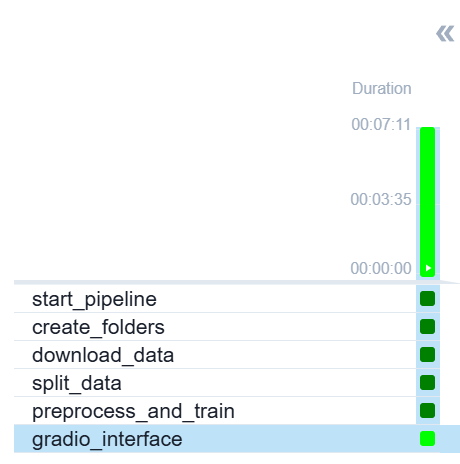

# Predicción para Vale
---
Se ingresó a los ``logs`` para obtener la URL pública de gradio y así ingresar el ``json`` entregado:

[2025-10-27T09:49:08.293+0000] {logging_mixin.py:188} INFO - Running on public URL: https://f96a606e3121dbf2f2.gradio.live

[2025-10-27T09:49:08.294+0000] {logging_mixin.py:188} INFO - 
This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)

[2025-10-27T09:49:09.419+0000] {_client.py:1025} INFO - HTTP Request: POST https://api.gradio.app/gradio-launched-telemetry/ "HTTP/1.1 200 OK"

[2025-10-27T09:50:44.815+0000] {logging_mixin.py:188} INFO - Error durante la predicción: 'NoneType' object has no attribute 'name'

[2025-10-27T09:51:43.797+0000] {logging_mixin.py:188} INFO - Predicción bruta: [0]

El resultado fue una predicción de no contratación, como se ve en la imagen adjunta: 

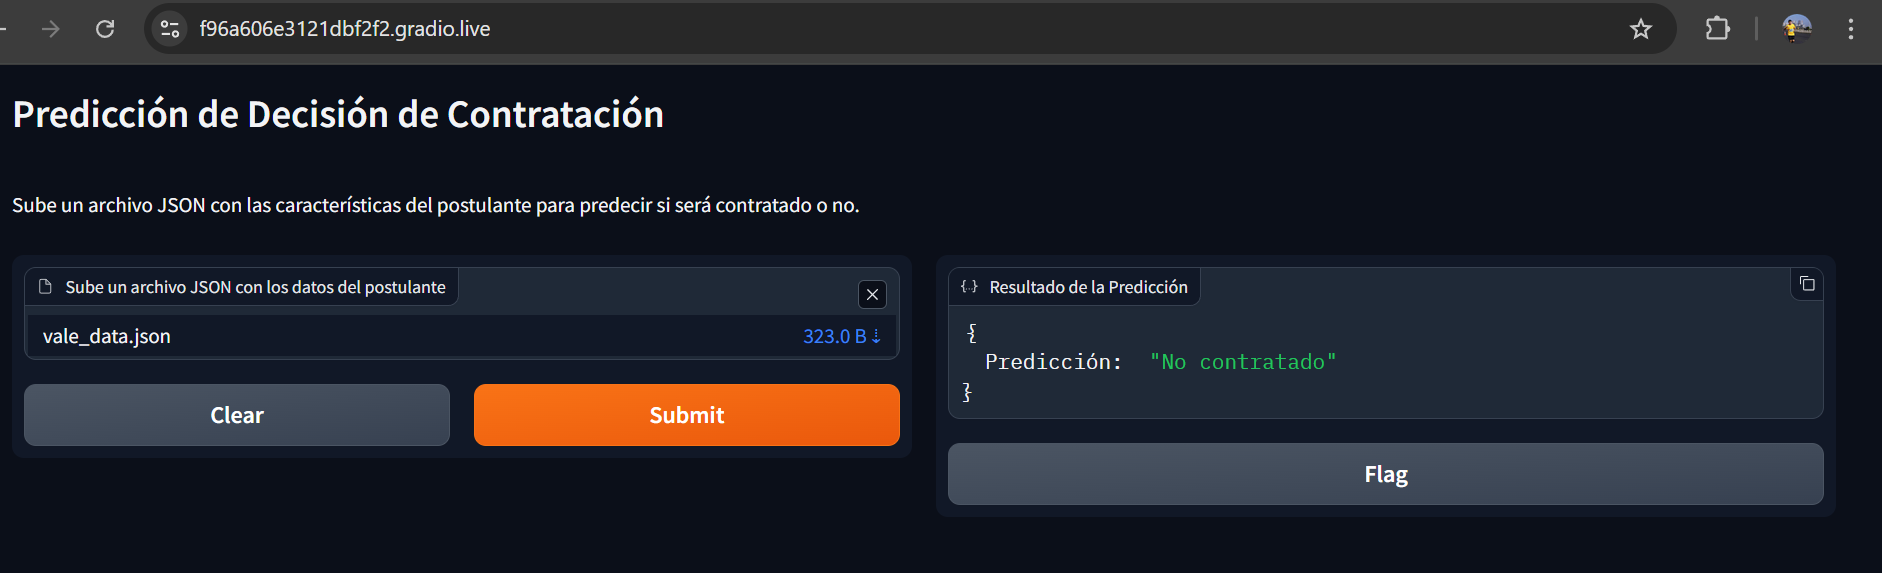

# **2. Paralelizando el Pipeline** (30 puntos)

<p align="center">
  <img src="https://i.gifer.com/8LNL.gif" width="400">
</p>



Al ver los resultados obtenidos, Vale queda muy contenta con el clasificador. Sin embargo, le aparecen algunas dudas respecto al funcionamiento del pipeline. Primero le comenta que es posible que en un futuro tenga nuevos datos que podrían ser útiles para realizar nuevos entrenamientos, por lo que sería ideal si este pipeline se fuera ejecutando de forma periódica y **NO** de forma manual. Además, Vale le menciona que le gustaría explorar el desempeño de otros modelos además de `Random Forest`, de forma que el pipeline seleccione de forma automática el modelo con mejor desempeño para luego hacer la predicción de Vale.

## **2.1 Preparando un Nuevo Pipeline** (15 puntos)

<p align="center">
  <img src="https://media.tenor.com/gnA7-5TewXMAAAAM/elle-woods.gif" width="400">
</p>

De acuerdo a lo que le comentó Vale, usted decide crear un nuevo script con las funciones que utilizará su pipeline. Por ende, dentro de la carpeta `dags`, usted creará el archivo `hiring_dynamic_functions.py` el cual debe contener:

1. (2 puntos) Una función llamada `create_folders()` que cree una carpeta, la cual utilice la fecha de ejecución como nombre. Adicionalmente, dentro de esta carpeta debe crear las siguientes subcarpetas:
  - raw
  - preprocessed
  - splits
  - models
2. (2 puntos) Una función llamada `load_ands_merge()` que lea desde la carpeta `raw` los archivos `data_1.csv`y `data_2.csv` en caso de estar disponible. Luego concatene estos y genere un nuevo archivo resultante, guardándolo en la carpeta `preprocessed`.

3. (2 puntos) Una función llamada `split_data()` que lea la data guardada en la carpeta `preprocessed` y realice un hold out sobre esta data. Esta función debe crear un conjunto de entrenamiento y uno de prueba. Mantenga una semilla y 20% para el conjunto de prueba. Guarde los conjuntos resultantes en la carpeta `splits`.

4. (6 puntos) Una función llamada `train_model()` que reciba un modelo de clasificación.
    - La función debe comenzar leyendo el conjunto de entrenamiento desde la carpeta `splits`.
    - Esta debe crear y aplicar un `Pipeline` con una etapa de preprocesamiento. Utilice `ColumnTransformers` para aplicar las transformaciones que estime convenientes.
    - Añada una etapa de entrenamiento utilizando un modelo que ingrese a la función.
  
  Esta función **debe crear un archivo joblib con el pipeline entrenado**. Guarde el modelo con un nombre que le permita una facil identificación dentro de la carpeta `models`.

5. (3 puntos) Una función llamada `evaluate_models()` que reciba sus modelos entrenados desde la carpeta `models`, evalúe su desempeño mediante `accuracy` en el conjunto de prueba y seleccione el mejor modelo obtenido. Luego guarde el mejor modelo como archivo `.joblib`. Su función debe imprimir el nombre del modelo seleccionado y el accuracy obtenido.

In [ ]:
from glob import glob 

#  1. Creación de Carpetas 

def create_folders(**kwargs):
    """
    Crea una estructura de carpetas basada en la fecha de ejecución (ds).
    Pasa las rutas de las carpetas creadas vía XCom.
    """
    # fecha de ejecución del contexto de Airflow
    execution_date = kwargs['ds']
    
    # ruta base en el directorio de trabajo actual
    base_path = Path.cwd() / execution_date
    
    # subcarpetas (incluyendo 'preprocessed')
    raw_path = base_path / 'raw'
    preprocessed_path = base_path / 'preprocessed' # Nueva carpeta
    splits_path = base_path / 'splits'
    models_path = base_path / 'models'
    
    folders_to_create = [
        base_path, raw_path, preprocessed_path, splits_path, models_path
    ]
    for path in folders_to_create:
        path.mkdir(parents=True, exist_ok=True)
        
    print(f"Carpetas creadas en: {base_path}")
    
    # diccionario con las rutas para que Airflow las pase por XCom
    return {
        'base_path': str(base_path),
        'raw_path': str(raw_path),
        'preprocessed_path': str(preprocessed_path),
        'splits_path': str(splits_path),
        'models_path': str(models_path)
    }

#  2. Carga y Fusión de Datos 

def load_and_merge(**kwargs):
    """
    Lee data_1.csv y (si existe) data_2.csv de la carpeta 'raw',
    los concatena y guarda el resultado en 'preprocessed'.
    
    Depende de:
    - XCom de la tarea 'create_folders'.
    - Archivos de datos en la carpeta 'raw'
    """
    #  rutas desde la tarea 'create_folders'
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders_task') 
    
    raw_path = Path(paths['raw_path'])
    preprocessed_path = Path(paths['preprocessed_path'])
    
    data_1_file = raw_path / 'data_1.csv'
    data_2_file = raw_path / 'data_2.csv'
    
    # Lista para almacenar los DataFrames a concatenar
    dfs_to_merge = []
    
    # Cargar data_1.csv 
    if data_1_file.exists():
        print(f"Leyendo {data_1_file}...")
        dfs_to_merge.append(pd.read_csv(data_1_file))
    else:
        raise FileNotFoundError(f"Archivo requerido {data_1_file} no encontrado.")

    # Cargar data_2.csv
    if data_2_file.exists():
        print(f"Leyendo {data_2_file}...")
        dfs_to_merge.append(pd.read_csv(data_2_file))
    else:
        print("data_2.csv no encontrado, se omitirá.")
        
    # Concatenar los DataFrames
    print("Concatenando archivos...")
    merged_df = pd.concat(dfs_to_merge, ignore_index=True)
    
    # Guardar en la carpeta 'preprocessed'
    output_file = preprocessed_path / 'merged_data.csv'
    merged_df.to_csv(output_file, index=False)
    
    print(f"Datos fusionados y guardados en: {output_file}")

#  3. División de Datos 

def split_data(**kwargs):
    """
    Lee los datos de 'preprocessed', aplica hold-out (80/20) estratificado
    y guarda los sets de train/test en 'splits'.
    
    Depende de:
    - XCom de la tarea 'create_folders_task'.
    - Archivo 'merged_data.csv' en la carpeta 'preprocessed'.
    """
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders_task') 
    
    preprocessed_path = Path(paths['preprocessed_path'])
    splits_path = Path(paths['splits_path'])
    
    input_file = preprocessed_path / 'merged_data.csv'
    
    print(f"Leyendo datos fusionados de: {input_file}")
    df = pd.read_csv(input_file)
    
    # features (X) y target (y)
    TARGET = 'HiringDecision'
    if TARGET not in df.columns:
        raise ValueError(f"La columna objetivo '{TARGET}' no se encuentra en los datos.")
        
    X = df.drop(TARGET, axis=1)
    y = df[TARGET]
    
    # Split 80/20 estratificado con semilla
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.20, 
        random_state=42,  # Semilla fija
        stratify=y         # Mantener proporción
    )
    
    # X e y para guardar los archivos CSV completos
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)
    
    # rutas de salida
    train_output = splits_path / 'train.csv'
    test_output = splits_path / 'test.csv'
    
    train_df.to_csv(train_output, index=False)
    test_df.to_csv(test_output, index=False)
    
    print(f"Datos de entrenamiento guardados en: {train_output}")
    print(f"Datos de prueba guardados en: {test_output}")

#  4. Entrenamiento de Modelo (Parametrizado) 

def train_model(model, model_name, **kwargs):
    """
    Función genérica para entrenar un modelo.
    Recibe una instancia del modelo y un nombre para guardarlo.
    
    Lee solo el set de entrenamiento de 'splits', define un pipeline,
    entrena y guarda el pipeline en 'models'.
    
    Args:
        model (sklearn.BaseEstimator): Instancia del clasificador (ej. RandomForestClassifier()).
        model_name (str): Nombre para el archivo (ej. "random_forest").
    
    Depende de:
    - XCom de la tarea 'create_folders_task'.
    - Archivo 'train.csv' en la carpeta 'splits'.
    """
    print(f" Iniciando entrenamiento para: {model_name} ")
    
    # rutas desde 'create_folders_task'
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders_task') 
    
    splits_path = Path(paths['splits_path'])
    models_path = Path(paths['models_path'])
    
    # solo los datos de entrenamiento
    print(f"Leyendo set de entrenamiento...")
    train_df = pd.read_csv(splits_path / 'train.csv')
    
    # features y target
    TARGET = 'HiringDecision'
    X_train = train_df.drop(TARGET, axis=1)
    y_train = train_df[TARGET]

    # Definición del Pipeline de Preprocesamiento 
    numeric_features = [
        'Age', 'ExperienceYears', 'PreviousCompanies', 
        'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore'
    ]
    categorical_features = ['Gender', 'EducationLevel', 'RecruitmentStrategy']

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough'
    )

    #  Definición del Pipeline Completo 
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) # Usamos el modelo pasado como argumento
    ])
    
    #  Entrenamiento 
    print(f"Entrenando pipeline con {model_name}...")
    pipeline.fit(X_train, y_train)
    print("Entrenamiento finalizado.")
    
    #  Guardado del Modelo 
    model_path = models_path / f'{model_name}.joblib'
    joblib.dump(pipeline, model_path)
    
    print(f"Pipeline de {model_name} guardado en: {model_path}")
    print(f" Finalizado entrenamiento para: {model_name} ")

#  5. Evaluación y Selección de Modelo 

def evaluate_models(**kwargs):
    """
    Lee todos los modelos entrenados de la carpeta 'models'
    y los evalúa contra el set de prueba de 'splits'.
    
    Selecciona el mejor modelo basado en 'accuracy', lo guarda
    como 'best_model.joblib' e imprime los resultados.
    
    Depende de:
    - XCom de la tarea 'create_folders_task'.
    - Archivo 'test.csv' en la carpeta 'splits'.
    - Archivos '.joblib' en la carpeta 'models' (generados por las tareas de 'train_model').
    """
    print(" Iniciando evaluación de modelos ")
    
    ti = kwargs['ti']
    paths = ti.xcom_pull(task_ids='create_folders_task') 
    
    splits_path = Path(paths['splits_path'])
    models_path = Path(paths['models_path'])
    
    # 1. Cargar el set de prueba
    print("Cargando set de prueba...")
    test_df = pd.read_csv(splits_path / 'test.csv')
    TARGET = 'HiringDecision'
    X_test = test_df.drop(TARGET, axis=1)
    y_test = test_df[TARGET]
    
    # 2. Encontrar todos los modelos entrenados
    model_files = [
        Path(f) for f in glob(str(models_path / '*.joblib')) 
        if Path(f).name != 'best_model.joblib'
    ]

    if not model_files:
        print("Error: No se encontraron modelos .joblib en la carpeta 'models'.")
        return

    print(f"Modelos encontrados: {[f.name for f in model_files]}")

    best_accuracy = -1.0
    best_model_pipeline = None
    best_model_name = ""

    # 3. Evaluar cada modelo
    for model_file in model_files:
        try:
            pipeline = joblib.load(model_file)
            model_name = model_file.stem # Obtiene el nombre del archivo sin extensión
            
            y_pred = pipeline.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            
            print(f"Modelo: {model_name} | Accuracy: {accuracy:.4f}")
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model_pipeline = pipeline
                best_model_name = model_name
                
        except Exception as e:
            print(f"Error al cargar o evaluar {model_file}: {e}")

    # 4. Seleccionar y guardar el mejor
    if best_model_pipeline:
        print(f"\n Selección Final ")
        print(f"Mejor Modelo: {best_model_name}")
        print(f"Mejor Accuracy: {best_accuracy:.4f}")
        
        best_model_path = models_path / 'best_model.joblib'
        joblib.dump(best_model_pipeline, best_model_path)
        
        print(f"Mejor modelo guardado en: {best_model_path}")
        
        # Devolver la ruta al mejor modelo para tareas futuras 
        return str(best_model_path)
    else:
        print("No se pudo seleccionar un mejor modelo.")

## **2.2 Componiendo un nuevo DAG** (15 puntos)

<p align="center">
  <img src="https://67.media.tumblr.com/bfa5208006dc3f404ec08e8c3195cf2c/tumblr_obg9tgnLfX1u9e9f2o2_r1_500.gif" width="500">
</p>

Con las nuevas funciones, se debe crear el nuevo nuevo DAG. Para ello, cree un nuevo script en la carpeta `dags`, llamandolo `dag_dynamic.py`. Este script debe contener la siguiente estructura:

1. (1 punto) Inicialice un DAG con fecha de inicio el 1 de octubre de 2024, el cual se debe ejecutar el día 5 de cada mes a las 15:00 UTC. Utilice un `dag_id` interpretable para identificar fácilmente. **Habilite el backfill** para que pueda ejecutar tareas programadas desde fechas pasadas.
2. (1 punto) Comience con un marcador de posición que indique el inicio del pipeline.
3. (2 puntos) Cree una carpeta correspondiente a la ejecución del pipeline y cree las subcarpetas `raw`, `preprocessed`, `splits` y `models` mediante la función `create_folders()`.
4. (2 puntos) Implemente un `Branching`que siga la siguiente lógica:
  - Fechas previas al 1 de noviembre de 2024: Se descarga solo `data_1.csv`
  - Desde el 1 de noviembre del 2024: descarga `data_1.csv` y `data_2.csv`.
  En el siguiente [enlace](https://gitlab.com/eduardomoyab/laboratorio-13/-/raw/main/files/data_2.csv) puede descargar `data_2.csv`.
5. (1 punto) Cree una tarea que concatene los datasets disponibles mediante la función `load_and_merge()`. Configure un `Trigger` para que la tarea se ejecute si encuentra disponible **como mínimo** uno de los archivos.
6. (1 punto) Aplique el hold out al dataset mediante la función `split_data()`, obteniendo un conjunto de entrenamiento y uno de prueba.
7. (2 puntos) Realice 3 entrenamientos en paralelo:
  - Un modelo Random Forest.
  - 2 modelos a elección.
  Asegúrese de guardar sus modelos entrenados con nombres distintivos. Utilice su función `train_model()` para ello.
8. (2 puntos) Mediante la función `evaluate_models()`, evalúe los modelos entrenados, registrando el accuracy de cada modelo en el set de prueba. Luego debe imprimir el mejor modelo seleccionado y su respectiva métrica. Configure un `Trigger` para que la tarea se ejecute solamente si los 3 modelos fueron entrenados y guardados.

`Hint:` Recuerde que puede entregar `kwargs` a sus funciones, como por ejemplo la fecha de ejecución `ds`.

Una vez creado el script, vuelva a construir el contenedor en Docker, acceda a la aplicación web de Airflow, ejecute su pipeline y muestre sus resultados. Adjunte imágenes que ayuden a mostrar el proceso y sus resultados.

Adicionalmente, responda (1 c/u):

- ¿Cual es el accuracy de cada modelo en la ejecución de octubre? ¿Se obtienen los mismos resultados a partir de Noviembre?
- Analice como afectó el añadir datos a sus modelos mediante el desempeño del modelo y en costo computacional.
- Muestre el esquema de su DAG ejecutado en octubre y en noviembre.


`Nota:` Para esta sección no debe implementar la tarea en gradio, solamente se espera determinar el mejor modelo y comparar el desempeño obtenido.

**IMPORTANTE: Para esta sección, debe adjuntar todos los scripts creados junto a su notebook en la entrega, ya que serán ejecutados para validar el funcionamiento. Para justificar sus respuestas, adicionalmente puede utilizar imágenes de apoyo, como screenshots.**

In [ ]:
import pendulum
from datetime import datetime
from airflow.models import DAG
from airflow.operators.empty import EmptyOperator
from airflow.operators.python import PythonOperator, BranchPythonOperator
from airflow.operators.bash import BashOperator
from airflow.utils.trigger_rule import TriggerRule

# Importaciones de Modelos de Scikit-learn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

try:
    from hiring_dynamic_functions import (
        create_folders,
        load_and_merge,
        split_data,
        train_model,
        evaluate_models
    )
except ImportError:
    print("Error importando hiring_dynamic_functions.py. Asegúrese de que esté en la carpeta dags.")
    # Placeholders para que el DAG se parsee
    def placeholder(*args, **kwargs): pass
    create_folders, load_and_merge, split_data, train_model, evaluate_models = (placeholder,) * 5


#  1. Inicialización del DAG  
with DAG(
    dag_id='hiring_dynamic',
    start_date=pendulum.datetime(2024, 10, 1, tz="UTC"),
    # Ejecutar el día 5 de cada mes a las 15:00 UTC (formato cron)
    schedule_interval='0 15 5 * *', 
    catchup=True,  # Habilitar backfill
    tags=['mlops', 'hiring', 'lab9_dynamic', 'parallel'],
    doc_md="Pipeline dinámico que entrena modelos en paralelo."
) as dag:

    #  2. Tarea de Inicio  
    start_pipeline = EmptyOperator(
        task_id='start_pipeline'
    )

    #  3. Tarea de Creación de Carpetas  
    create_folders_task = PythonOperator(
        task_id='create_folders_task',
        python_callable=create_folders
    )

    #  4. Tarea de Branching (Lógica de Fechas)  
    
    def check_date_branch(**kwargs):
        """
        Decide qué ramas de descarga ejecutar basado en la fecha de ejecución.
        """
        execution_date_str = kwargs['ds'] # 'YYYY-MM-DD'
        execution_date = datetime.strptime(execution_date_str, '%Y-%m-%d').date()
        
        # Fecha límite es 1 de Noviembre 2024
        threshold_date = datetime(2024, 11, 1).date()
        
        if execution_date < threshold_date:
            # Ejecuciones de Octubre
            print(f"Fecha {execution_date}: Descargando solo data_1.")
            return 'download_data_1_task' # ID de la tarea a ejecutar
        else:
            # Ejecuciones de Noviembre 2024 en adelante
            print(f"Fecha {execution_date}: Descargando data_1 y data_2.")
            return ['download_data_1_task', 'download_data_2_task'] # IDs de ambas tareas

    branching_task = BranchPythonOperator(
        task_id='check_date_branch',
        python_callable=check_date_branch
    )

    #  Tareas de Descarga (controladas por el Branching)  
    
    DATA_1_URL = "https://gitlab.com/eduardomoyab/laboratorio-13/-/raw/main/files/data_1.csv"
    DATA_2_URL = "https://gitlab.com/eduardomoyab/laboratorio-13/-/raw/main/files/data_2.csv"
    
    # Plantillas Jinja para obtener la ruta 'raw' desde XCom
    output_path_1 = "{{ ti.xcom_pull(task_ids='create_folders_task')['raw_path'] }}/data_1.csv"
    output_path_2 = "{{ ti.xcom_pull(task_ids='create_folders_task')['raw_path'] }}/data_2.csv"
    
    download_data_1_task = BashOperator(
        task_id='download_data_1_task',
        bash_command=f"curl -sSL -o {output_path_1} {DATA_1_URL}"
    )
    
    download_data_2_task = BashOperator(
        task_id='download_data_2_task',
        bash_command=f"curl -sSL -o {output_path_2} {DATA_2_URL}"
    )

    #  5. Tarea de Fusión de Datos  
    load_and_merge_task = PythonOperator(
        task_id='load_and_merge',
        python_callable=load_and_merge,
        # Trigger: Se ejecuta si AL MENOS UNA de sus tareas padres (download_1 o download_2) tuvo éxito.
        trigger_rule=TriggerRule.ONE_SUCCESS
    )

    #  6. Tarea de División de Datos  
    split_data_task = PythonOperator(
        task_id='split_data',
        python_callable=split_data
    )

    #  7. Tareas de Entrenamiento en Paralelo  
    
    # Lista para agrupar las tareas de entrenamiento
    training_tasks = []

    # Modelo 1: Random Forest
    train_rf_task = PythonOperator(
        task_id='train_random_forest',
        python_callable=train_model,
        op_kwargs={
            'model': RandomForestClassifier(random_state=42),
            'model_name': 'random_forest'
        }
    )
    training_tasks.append(train_rf_task)

    # Modelo 2: Regresión Logística 
    train_lr_task = PythonOperator(
        task_id='train_logistic_regression',
        python_callable=train_model,
        op_kwargs={
            'model': LogisticRegression(random_state=42, max_iter=1000),
            'model_name': 'logistic_regression'
        }
    )
    training_tasks.append(train_lr_task)

    # Modelo 3: Gradient Boosting 
    train_gb_task = PythonOperator(
        task_id='train_gradient_boosting',
        python_callable=train_model,
        op_kwargs={
            'model': GradientBoostingClassifier(random_state=42),
            'model_name': 'gradient_boosting'
        }
    )
    training_tasks.append(train_gb_task)

    #  8. Tarea de Evaluación y Selección  
    evaluate_models_task = PythonOperator(
        task_id='evaluate_models',
        python_callable=evaluate_models,
        trigger_rule=TriggerRule.ALL_SUCCESS
    )


    #  Definición de Dependencias 
    
    # 1. Inicio
    start_pipeline >> create_folders_task
    
    # 2. Branching para descarga
    create_folders_task >> branching_task >> [download_data_1_task, download_data_2_task]
    
    # 3. Merge 
    [download_data_1_task, download_data_2_task] >> load_and_merge_task
    
    # 4. Split
    load_and_merge_task >> split_data_task
    
    # 5. Entrenamiento en paralelo
    split_data_task >> training_tasks
    
    # 6. Evaluación 
    training_tasks >> evaluate_models_task

## Respuestas
---

### Desempeño de los Modelos (Accuracy)

Se evaluaron tres modelos de clasificación (Random Forest, Logistic Regression y Gradient Boosting) utilizando la métrica de **accuracy** sobre el conjunto de prueba correspondiente a cada ejecución mensual.

#### Ejecución de Octubre 2024 (Usando solo `data_1.csv`)

Los accuracies obtenidos fueron los siguientes:

* **Random Forest:** 0.9133
* **Gradient Boosting:** 0.9067
* **Logistic Regression:** 0.9133

En esta ejecución, hubo un **empate** entre Random Forest y Logistic Regression como los modelos con mejor desempeño, alcanzando un accuracy de **0.9133**.

#### Ejecución de Noviembre 2024 (Usando `data_1.csv` + `data_2.csv`)

Al incluir el segundo conjunto de datos, los accuracies cambiaron:

* **Random Forest:** 0.9233 (+0.0100)
* **Gradient Boosting:** 0.9333 (+0.0266)
* **Logistic Regression:** 0.9067 (-0.0066)

Los resultados **no son los mismos** a partir de Noviembre. La adición de nuevos datos (`data_2.csv`) **mejoró significativamente el desempeño** de los modelos basados en árboles (Random Forest y, especialmente, Gradient Boosting), mientras que el modelo lineal (Logistic Regression) experimentó una ligera disminución en su accuracy. El **Gradient Boosting se convirtió en el mejor modelo** en Noviembre, alcanzando un accuracy de **0.9333**. Esto sugiere que los datos adicionales introdujeron patrones (posiblemente no lineales) que Gradient Boosting pudo capturar de manera más efectiva.

---

### Costo Computacional

Se analizó el impacto de añadir datos en el tiempo de ejecución (costo computacional).

#### Duración Total del DAG Run

* **Octubre 2024:** 00:06:03
* **Noviembre 2024:** 00:05:58

La duración total del pipeline fue ligeramente **menor** en Noviembre. 

#### Duración de Tareas Individuales (Entrenamiento)

Sin embargo, un análisis más detallado de las tareas de entrenamiento revela lo siguiente:

| Tarea                      | Duración Octubre 2024 | Duración Noviembre 2024 | Diferencia    |
| :------------------------- | :-------------------- | :---------------------- | :------------ |
| `train_random_forest`      | 13 segundos           | 14 segundos             | **+1 segundo** |
| `train_logistic_regression`| 16 segundos           | 11 segundos             | **-5 segundos** |
| `train_gradient_boosting`  | 14 segundos           | 15 segundos             | **+1 segundo** |

* Los modelos **Random Forest** y **Gradient Boosting**, que son computacionalmente más complejos y sensibles al tamaño de los datos, **mostraron un incremento** en su tiempo de entrenamiento al procesar el doble de datos en Noviembre. Esto confirma que añadir datos sí **aumenta el costo computacional** para estos algoritmos.
* La **Regresión Logística** fue inesperadamente más rápida en Noviembre. Esto podría atribuirse a la **variabilidad del sistema** en tareas de corta duración o, menos probablemente, a una convergencia más rápida del algoritmo con el dataset combinado.
* A pesar de la variabilidad observada en el tiempo total y en la Regresión Logística, la tendencia fundamental se mantiene: procesar y entrenar modelos con **más datos generalmente implica un mayor costo computacional**, especialmente para algoritmos más complejos.

---
## DAG ejecutado en octubre y en noviembre
### DAG ejecutado en octubre
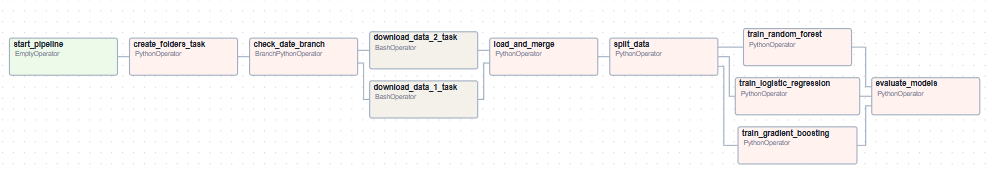
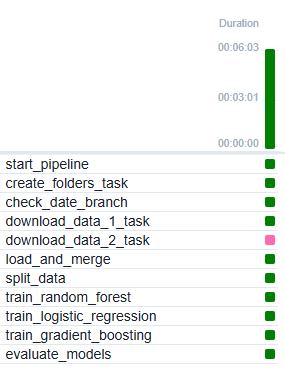
### DAG ejecutado en noviembre
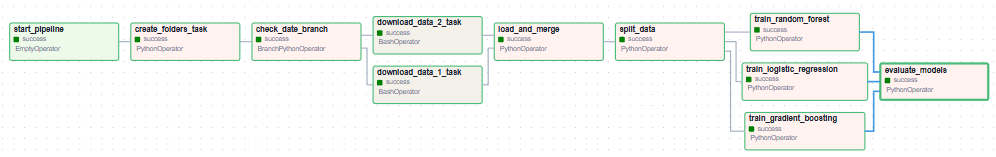
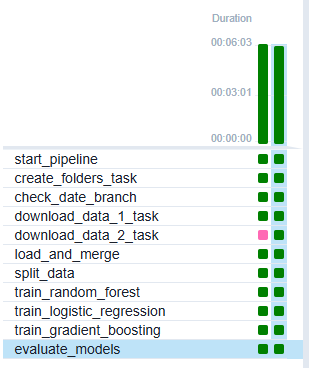


DAGs del Laboratorio
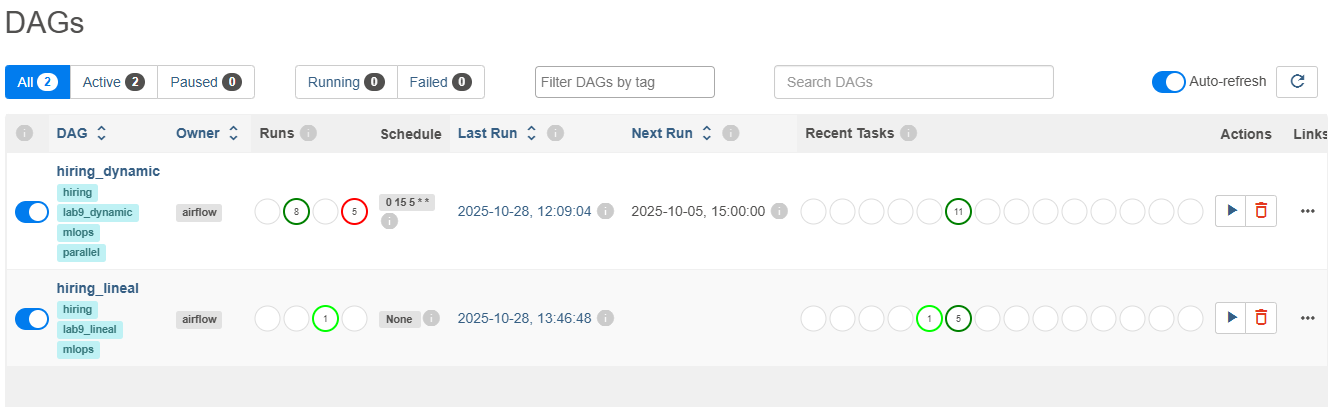